In [1]:
# cell 1: imports and data loading for model a (sentiment) + running the logistic regression baseline
import time
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

print("loading features and labels for model a...")

# load sparse matrices
x_train_a = sp.load_npz('data/features/model_a_x_train.npz')
x_test_a = sp.load_npz('data/features/model_a_x_test.npz')

# load labels (y is usually a 1d array, so we squeeze the dataframe)
y_train_a = pd.read_csv('data/features/model_a_y_train.csv').squeeze()
y_test_a = pd.read_csv('data/features/model_a_y_test.csv').squeeze()

print(f"x_train shape: {x_train_a.shape}, y_train shape: {y_train_a.shape}")
print(f"x_test shape: {x_test_a.shape}, y_test shape: {y_test_a.shape}")

# 1. initialize and train the model
print("\ntraining logistic regression baseline...")
start_time = time.time()

# max_iter=1000 ensures the algorithm has enough time to converge
model_a_logreg = LogisticRegression(max_iter=1000, random_state=42)

# this is where the actual learning happens
model_a_logreg.fit(x_train_a, y_train_a)

# 2. make predictions on the unseen test set
print("making predictions on the test set...")
y_pred_a = model_a_logreg.predict(x_test_a)

print(f"training time       : {time.time() - start_time:.4f} seconds")
print(f"real number of iterations to converge: {model_a_logreg.n_iter_[0]}\n")

# 3. evaluate the results
print("\n--- classification report ---")
# target_names correspond to classes 0, 1, 2
print(classification_report(y_test_a, y_pred_a, target_names=['negative', 'positive', 'neutral']))

loading features and labels for model a...
x_train shape: (31247, 10000), y_train shape: (31247,)
x_test shape: (7812, 10000), y_test shape: (7812,)

training logistic regression baseline...
making predictions on the test set...
training time       : 5.5417 seconds
real number of iterations to converge: 58


--- classification report ---
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      2500
    positive       0.86      0.88      0.87      2500
     neutral       0.98      1.00      0.99      2812

    accuracy                           0.91      7812
   macro avg       0.91      0.91      0.91      7812
weighted avg       0.91      0.91      0.91      7812



### training strategy for model b (emotions)

**problem:** model b is a multi-label task where each text can have multiple emotions simultaneously. standard `logisticregression` supports only one label per input.

**solution: one-vs-rest (ovr) strategy**
I wrapped the base model in `onevsrestclassifier`. this approach:
* splits the 9-emotion task into 9 independent binary classification problems.
* trains a separate logistic regression for each emotion (e.g., "joy" vs "not joy").
* allows predicting multiple active labels for a single text by checking each model's output.

**result:** I handle emotional complexity without switching to more resource-heavy architectures at the baseline stage.

In [4]:
# cell 2: training baselines for model b (emotions) and model c (formality)
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# --- model b: emotions (multi-label) ---
print("loading data for model b...")
x_train_b = sp.load_npz('data/features/model_b_x_train.npz')
x_test_b = sp.load_npz('data/features/model_b_x_test.npz')
y_train_b = pd.read_csv('data/features/model_b_y_train.csv')
y_test_b = pd.read_csv('data/features/model_b_y_test.csv')

print("training one-vs-rest logistic regression for emotions...")
# wrapping logistic regression to handle 9 independent classes
base_lr = LogisticRegression(max_iter=1000, random_state=42)
model_b_logreg_ovr = OneVsRestClassifier(base_lr)
model_b_logreg_ovr.fit(x_train_b, y_train_b)

print("evaluating model b...")
y_pred_b = model_b_logreg_ovr.predict(x_test_b)
print("\n--- classification report (model b) ---")
print(classification_report(y_test_b, y_pred_b, target_names=y_train_b.columns, zero_division=0))
print(f"real number of iterations to converge for each emotion: {[int(est.n_iter_[0]) for est in model_b_logreg_ovr.estimators_]}")


# --- model c: formality (binary/multiclass) ---
print("\nloading data for model c...")
x_train_c = sp.load_npz('data/features/model_c_x_train.npz')
x_test_c = sp.load_npz('data/features/model_c_x_test.npz')
# squeezing to 1d array for standard logistic regression
y_train_c = pd.read_csv('data/features/model_c_y_train.csv').squeeze()
y_test_c = pd.read_csv('data/features/model_c_y_test.csv').squeeze()

print("training logistic regression for formality...")
model_c_logreg = LogisticRegression(max_iter=1000, random_state=42)
model_c_logreg.fit(x_train_c, y_train_c)

print("evaluating model c...")
y_pred_c = model_c_logreg.predict(x_test_c)
print("\n--- classification report (model c) ---")
print(classification_report(y_test_c, y_pred_c, target_names=['informal', 'formal']))
print(f"real number of iterations to converge: {model_c_logreg.n_iter_[0]}")

loading data for model b...
training one-vs-rest logistic regression for emotions...
evaluating model b...

--- classification report (model b) ---
              precision    recall  f1-score   support

     sadness       0.80      0.28      0.41       260
       anger       0.78      0.46      0.58       766
        fear       0.83      0.19      0.31       131
     disgust       0.91      0.13      0.22       167
anticipation       0.82      0.48      0.61       439
         joy       0.89      0.64      0.74       942
    surprise       0.85      0.30      0.44       409
   gratitude       0.98      0.83      0.90       551
        love       0.92      0.74      0.82       408

   micro avg       0.88      0.53      0.66      4073
   macro avg       0.87      0.45      0.56      4073
weighted avg       0.87      0.53      0.64      4073
 samples avg       0.56      0.54      0.55      4073

real number of iterations to converge for each emotion: [23, 40, 20, 24, 36, 36, 25, 26, 19]


In [24]:
# cell 3: interactive testing of baseline models (with probabilities)
import joblib
import numpy as np

print("loading frozen vectorizers using joblib...")
# ensure the paths match the exact filenames saved in stage 3
vectorizer_a = joblib.load('models/vectorizers/tfidf_model_a.pkl')
vectorizer_b = joblib.load('models/vectorizers/tfidf_model_b.pkl')
vectorizer_c = joblib.load('models/vectorizers/tfidf_model_c.pkl')

def predict_text(text):
    """processes text and outputs probabilities for all classes."""
    print(f"\n" + "="*70)
    print(f"text: \"{text}\"")
    print("="*70)
    
    # 1. model a (sentiment)
    vec_a = vectorizer_a.transform([text])
    # predict_proba returns a 2d array, we take the first row [0]
    proba_a = model_a_logreg.predict_proba(vec_a)[0]
    classes_a = ['negative', 'positive', 'neutral']
    
    print("\n[ model a: sentiment ] (softmax - sum is 100%)")
    for cls, prob in zip(classes_a, proba_a):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    winner_a = classes_a[np.argmax(proba_a)]
    print(f"  -> final result: {winner_a}")
    
    # 2. model b (emotions)
    vec_b = vectorizer_b.transform([text])
    proba_b = model_b_logreg_ovr.predict_proba(vec_b)[0]
    classes_b = y_train_b.columns.tolist()
    
    print("\n[ model b: emotions ] (independent sigmoids - threshold > 50%)")
    active_emotions = []
    for cls, prob in zip(classes_b, proba_b):
        print(f"  {cls:<12}: {prob*100:>5.1f}%")
        if prob >= 0.5:
            active_emotions.append(cls)
            
    if not active_emotions:
        print("  -> active emotions: none detected (neutral)")
    else:
        print(f"  -> active emotions: {', '.join(active_emotions)}")
        
    # 3. model c (formality)
    vec_c = vectorizer_c.transform([text])
    proba_c = model_c_logreg.predict_proba(vec_c)[0]
    classes_c = ['informal', 'formal']
    
    print("\n[ model c: formality ] (softmax)")
    for cls, prob in zip(classes_c, proba_c):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    winner_c = classes_c[np.argmax(proba_c)]
    print(f"  -> final result: {winner_c}")

# run tests on edge-case texts
text_sarcasm = "I am absolutely thrilled that my flight was delayed by 12 hours. The stale sandwich provided a profound sense of culinary joy."
text_panic = "omg omg omg i literally can't breathe I just got the tickets and I'm shaking so much this is terrifyingly amazing!!! AAAAAAA"
text_melancholy = "Saying goodbye to this house breaks my heart into a million pieces, but I will forever cherish the beautiful memories we built within these walls. Thank you for everything."

predict_text(text_sarcasm)
predict_text(text_panic)
predict_text(text_melancholy)

loading frozen vectorizers using joblib...

text: "I am absolutely thrilled that my flight was delayed by 12 hours. The stale sandwich provided a profound sense of culinary joy."

[ model a: sentiment ] (softmax - sum is 100%)
  negative  :   1.6%
  positive  :   2.3%
  neutral   :  96.1%
  -> final result: neutral

[ model b: emotions ] (independent sigmoids - threshold > 50%)
  sadness     :   4.5%
  anger       :  20.6%
  fear        :   3.3%
  disgust     :   6.9%
  anticipation:   6.0%
  joy         :  25.9%
  surprise    :  11.4%
  gratitude   :   5.5%
  love        :   2.9%
  -> active emotions: none detected (neutral)

[ model c: formality ] (softmax)
  informal  :  65.0%
  formal    :  35.0%
  -> final result: informal

text: "omg omg omg i literally can't breathe I just got the tickets and I'm shaking so much this is terrifyingly amazing!!! AAAAAAA"

[ model a: sentiment ] (softmax - sum is 100%)
  negative  :   0.2%
  positive  :   1.1%
  neutral   :  98.7%
  -> final result

### baseline testing conclusions

**what works well:**
* **explicit markers:** tf-idf successfully catches strong, unambiguous words (e.g., "thank you" for gratitude, "terrifyingly" for surprise/fear).
* **formality separation:** the lexical difference between formal and informal text is distinct enough for a linear model to capture effectively.

**where the baseline fails:**
* **shortcut learning:** model a heavily defaults to "neutral" for short texts, relying on vector density (length) rather than semantic meaning, due to the structural differences between our imdb and reddit datasets.
* **context blindness:** tf-idf is a "bag of words" approach. it completely misses sarcasm, negated context, and implicit emotions where meaning is derived from the situation, not specific trigger words.

generating performance visualizations...


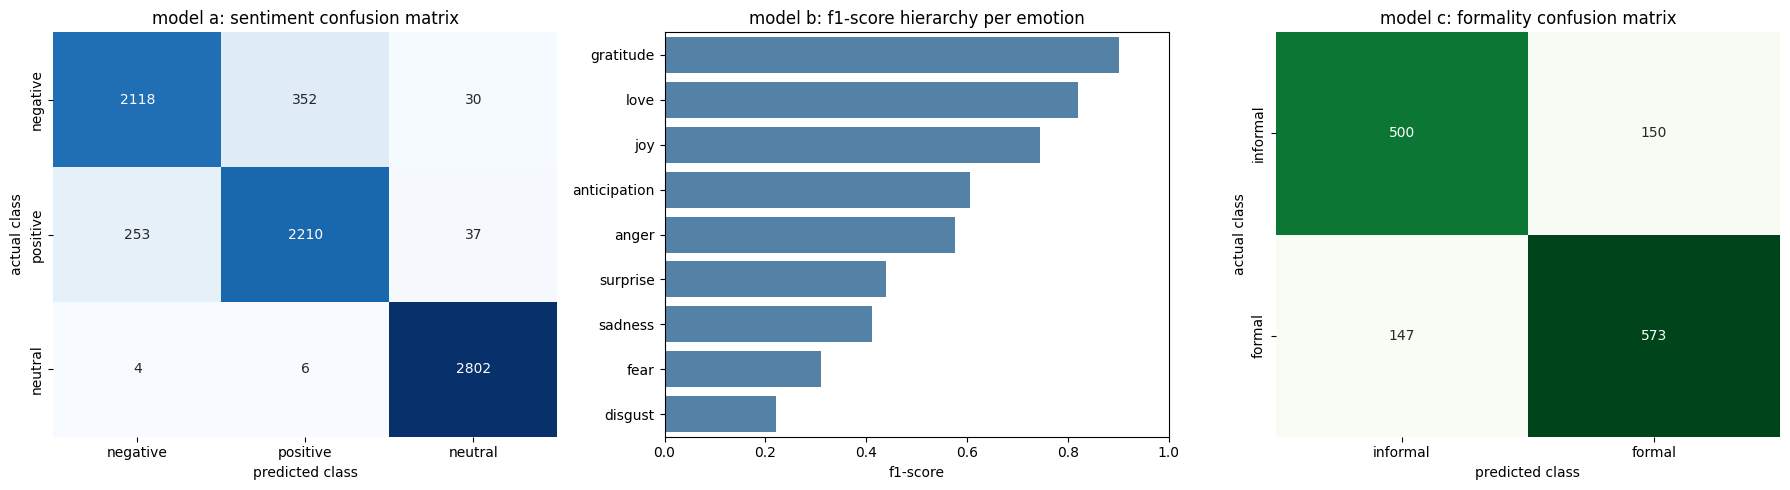

In [6]:
# cell 4: visualization of baseline performance metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print("generating performance visualizations...")

# initialize a 1x3 grid for plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. model a: sentiment confusion matrix ---
cm_a = confusion_matrix(y_test_a, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['negative', 'positive', 'neutral'],
            yticklabels=['negative', 'positive', 'neutral'],
            cbar=False)
axes[0].set_title('model a: sentiment confusion matrix')
axes[0].set_xlabel('predicted class')
axes[0].set_ylabel('actual class')

# --- 2. model b: f1-scores by emotion ---
# extract metrics from classification report
report_b = classification_report(y_test_b, y_pred_b, target_names=y_train_b.columns, output_dict=True, zero_division=0)
# filter out average metrics, keep only emotions
f1_scores = {emo: report_b[emo]['f1-score'] for emo in y_train_b.columns}
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['emotion', 'f1_score'])
# sort for better visual hierarchy
f1_df = f1_df.sort_values(by='f1_score', ascending=False)

sns.barplot(x='f1_score', y='emotion', data=f1_df, ax=axes[1], color='steelblue')
axes[1].set_title('model b: f1-score hierarchy per emotion')
axes[1].set_xlabel('f1-score')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1.0)

# --- 3. model c: formality confusion matrix ---
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['informal', 'formal'],
            yticklabels=['informal', 'formal'],
            cbar=False)
axes[2].set_title('model c: formality confusion matrix')
axes[2].set_xlabel('predicted class')
axes[2].set_ylabel('actual class')

# adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

In [7]:
# cell 5: training multinomial naive bayes for model a (sentiment)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import time

print("training multinomial naive bayes...")
start_time = time.time()

# alpha=1.0 applies standard laplace smoothing
model_a_nb = MultinomialNB(alpha=1.0)
model_a_nb.fit(x_train_a, y_train_a)

y_pred_nb = model_a_nb.predict(x_test_a)
acc_nb = accuracy_score(y_test_a, y_pred_nb)

print(f"multinomial naive bayes accuracy : {acc_nb:.4f}")
print(f"training time                    : {time.time() - start_time:.4f} seconds\n")

print("--- classification report (naive bayes) ---")
print(classification_report(y_test_a, y_pred_nb, target_names=['negative', 'positive', 'neutral']))

training multinomial naive bayes...
multinomial naive bayes accuracy : 0.8423
training time                    : 0.0102 seconds

--- classification report (naive bayes) ---
              precision    recall  f1-score   support

    negative       0.79      0.82      0.81      2500
    positive       0.79      0.85      0.82      2500
     neutral       0.95      0.86      0.90      2812

    accuracy                           0.84      7812
   macro avg       0.84      0.84      0.84      7812
weighted avg       0.85      0.84      0.84      7812



In [8]:
# cell 6: training naive bayes for model b (emotions) and model c (formality)
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
import time

# --- model b: emotions (multi-label) ---
print("training one-vs-rest naive bayes for emotions (model b)...")
start_time = time.time()

base_nb = MultinomialNB(alpha=1.0)
model_b_nb_ovr = OneVsRestClassifier(base_nb)
model_b_nb_ovr.fit(x_train_b, y_train_b)

y_pred_nb_b = model_b_nb_ovr.predict(x_test_b)
print(f"training time: {time.time() - start_time:.4f} seconds\n")

print("--- classification report (model b - naive bayes) ---")
print(classification_report(y_test_b, y_pred_nb_b, target_names=y_train_b.columns, zero_division=0))


# --- model c: formality (binary/multiclass) ---
print("\ntraining naive bayes for formality (model c)...")
start_time = time.time()

model_c_nb = MultinomialNB(alpha=1.0)
model_c_nb.fit(x_train_c, y_train_c)

y_pred_nb_c = model_c_nb.predict(x_test_c)
print(f"training time: {time.time() - start_time:.4f} seconds\n")

print("--- classification report (model c - naive bayes) ---")
print(classification_report(y_test_c, y_pred_nb_c, target_names=['informal', 'formal'], zero_division=0))

training one-vs-rest naive bayes for emotions (model b)...
training time: 0.0285 seconds

--- classification report (model b - naive bayes) ---
              precision    recall  f1-score   support

     sadness       0.82      0.07      0.13       260
       anger       0.87      0.24      0.37       766
        fear       1.00      0.04      0.07       131
     disgust       1.00      0.02      0.05       167
anticipation       0.87      0.13      0.23       439
         joy       0.92      0.35      0.50       942
    surprise       0.88      0.05      0.10       409
   gratitude       0.97      0.55      0.71       551
        love       0.94      0.23      0.37       408

   micro avg       0.92      0.25      0.39      4073
   macro avg       0.92      0.19      0.28      4073
weighted avg       0.91      0.25      0.37      4073
 samples avg       0.27      0.26      0.26      4073


training naive bayes for formality (model c)...
training time: 0.0012 seconds

--- classificatio

In [9]:
# cell 7: interactive testing with naive bayes models
import numpy as np

def predict_text_nb(text):
    """processes text and outputs probabilities using the naive bayes models."""
    print(f"\n" + "="*70)
    print(f"text: \"{text}\"")
    print("="*70)
    
    # 1. model a (sentiment) - naive bayes
    vec_a = vectorizer_a.transform([text])
    proba_a = model_a_nb.predict_proba(vec_a)[0]
    classes_a = ['negative', 'positive', 'neutral']
    
    print("\n[ model a (naive bayes): sentiment ]")
    for cls, prob in zip(classes_a, proba_a):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    winner_a = classes_a[np.argmax(proba_a)]
    print(f"  -> final result: {winner_a}")
    
    # 2. model b (emotions) - naive bayes
    vec_b = vectorizer_b.transform([text])
    proba_b = model_b_nb_ovr.predict_proba(vec_b)[0]
    classes_b = y_train_b.columns.tolist()
    
    print("\n[ model b (naive bayes): emotions ]")
    active_emotions = []
    for cls, prob in zip(classes_b, proba_b):
        print(f"  {cls:<12}: {prob*100:>5.1f}%")
        if prob >= 0.5:
            active_emotions.append(cls)
            
    if not active_emotions:
        print("  -> active emotions: none detected (neutral)")
    else:
        print(f"  -> active emotions: {', '.join(active_emotions)}")
        
    # 3. model c (formality) - naive bayes
    vec_c = vectorizer_c.transform([text])
    proba_c = model_c_nb.predict_proba(vec_c)[0]
    classes_c = ['informal', 'formal']
    
    print("\n[ model c (naive bayes): formality ]")
    for cls, prob in zip(classes_c, proba_c):
        print(f"  {cls:<10}: {prob*100:>5.1f}%")
    winner_c = classes_c[np.argmax(proba_c)]
    print(f"  -> final result: {winner_c}")

# test the same strings we defined in cell 3
predict_text_nb(text_sarcasm)
predict_text_nb(text_panic)
predict_text_nb(text_melancholy)


text: "I am absolutely thrilled that my flight was delayed by 12 hours. The stale sandwich provided a profound sense of culinary joy."

[ model a (naive bayes): sentiment ]
  negative  :  26.9%
  positive  :  29.2%
  neutral   :  43.9%
  -> final result: neutral

[ model b (naive bayes): emotions ]
  sadness     :   3.1%
  anger       :  12.7%
  fear        :   1.6%
  disgust     :   2.4%
  anticipation:   4.1%
  joy         :  17.8%
  surprise    :   7.4%
  gratitude   :  10.2%
  love        :   7.1%
  -> active emotions: none detected (neutral)

[ model c (naive bayes): formality ]
  informal  :  63.1%
  formal    :  36.9%
  -> final result: informal

text: "omg omg omg i literally can't breathe I just got the tickets and I'm shaking so much this is terrifyingly amazing!!! AAAAAAA"

[ model a (naive bayes): sentiment ]
  negative  :  13.3%
  positive  :  18.1%
  neutral   :  68.6%
  -> final result: neutral

[ model b (naive bayes): emotions ]
  sadness     :   2.6%
  anger       : 

### naive bayes testing conclusions

**what works well:**
* **training speed:** lightning-fast execution (fractions of a second). it calculates probabilities in a single pass without iterative gradient descent.
* **balanced binary tasks:** performs acceptably on model c (formality) where the dataset distribution is relatively equal.

**where naive bayes fails:**
* **the prior probability trap:** in imbalanced multi-label tasks (model b), the baseline mathematical penalty for rare emotions is too harsh. this forces probabilities artificially low, causing the default 50% threshold to block almost all positive predictions (resulting in catastrophic recall).
* **the "naive" assumption:** assuming complete word independence completely breaks down on slang and complex sentences (e.g., classifying a panic-filled "omg" text as formal due to the presence of longer words).

In [2]:
# cell 8: training Support Vector Machine (linear svc) for model a (sentiment)
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

print("training linear svc (support vector machine) for model a...")
start_time = time.time()

# dual='auto' is best practice for sparse tf-idf matrices in modern scikit-learn
# max_iter is increased to ensure the algorithm finds the perfect margin
model_a_svc = LinearSVC(random_state=42, dual='auto', max_iter=2000)
model_a_svc.fit(x_train_a, y_train_a)

y_pred_svc_a = model_a_svc.predict(x_test_a)
acc_svc_a = accuracy_score(y_test_a, y_pred_svc_a)

print(f"linear svc accuracy : {acc_svc_a:.4f}")
print(f"training time       : {time.time() - start_time:.4f} seconds")
print(f"real number of iterations to converge: {model_a_svc.n_iter_}\n")

print("--- classification report (model a - linear svc) ---")
print(classification_report(y_test_a, y_pred_svc_a, target_names=['negative', 'positive', 'neutral']))

training linear svc (support vector machine) for model a...
linear svc accuracy : 0.9156
training time       : 1.5577 seconds
real number of iterations to converge: 10

--- classification report (model a - linear svc) ---
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      2500
    positive       0.86      0.89      0.88      2500
     neutral       0.98      1.00      0.99      2812

    accuracy                           0.92      7812
   macro avg       0.91      0.91      0.91      7812
weighted avg       0.92      0.92      0.92      7812



In [5]:
# cell 9: training linear svc for model b (emotions) and model c (formality)
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
import time

# --- model b: emotions (multi-label) ---
print("training one-vs-rest linear svc for emotions (model b)...")
start_time = time.time()

base_svc = LinearSVC(random_state=42, dual='auto', max_iter=2000)
model_b_svc_ovr = OneVsRestClassifier(base_svc)
model_b_svc_ovr.fit(x_train_b, y_train_b)

y_pred_svc_b = model_b_svc_ovr.predict(x_test_b)
print(f"training time: {time.time() - start_time:.4f} seconds")
print(f"real number of iterations to converge for each emotion: {[est.n_iter_ for est in model_b_svc_ovr.estimators_]}\n")

print("--- classification report (model b - linear svc) ---")
print(classification_report(y_test_b, y_pred_svc_b, target_names=y_train_b.columns, zero_division=0))


# --- model c: formality (binary/multiclass) ---
print("\ntraining linear svc for formality (model c)...")
start_time = time.time()

model_c_svc = LinearSVC(random_state=42, dual='auto', max_iter=2000)
model_c_svc.fit(x_train_c, y_train_c)

y_pred_svc_c = model_c_svc.predict(x_test_c)
print(f"training time: {time.time() - start_time:.4f} seconds")
print(f"real number of iterations to converge: {model_c_svc.n_iter_}\n")

print("--- classification report (model c - linear svc) ---")
print(classification_report(y_test_c, y_pred_svc_c, target_names=['informal', 'formal'], zero_division=0))

training one-vs-rest linear svc for emotions (model b)...
training time: 0.1730 seconds
real number of iterations to converge for each emotion: [10, 11, 12, 11, 11, 11, 11, 12, 11]

--- classification report (model b - linear svc) ---
              precision    recall  f1-score   support

     sadness       0.77      0.46      0.58       260
       anger       0.71      0.58      0.64       766
        fear       0.78      0.50      0.61       131
     disgust       0.74      0.29      0.41       167
anticipation       0.75      0.56      0.65       439
         joy       0.85      0.70      0.77       942
    surprise       0.70      0.44      0.54       409
   gratitude       0.96      0.87      0.92       551
        love       0.87      0.79      0.83       408

   micro avg       0.81      0.63      0.71      4073
   macro avg       0.79      0.58      0.66      4073
weighted avg       0.80      0.63      0.70      4073
 samples avg       0.65      0.64      0.64      4073


train

### support vector machine (linear svc) conclusions

**what works well:**
* **solving the recall crisis:** by abandoning probabilities and prior distributions in favor of geometric margins, svm massively improves recall for minority classes in multi-label tasks (model b). it successfully identifies rare emotions that logistic regression and naive bayes missed.
* **efficiency:** converges significantly faster (fewer iterations) than logistic regression on highly sparse tf-idf matrices.

**where it hits the ceiling:**
* **the tf-idf limit:** despite optimal hyperplanes, accuracy on model a and model c barely moved compared to logistic regression. this proves the algorithms have extracted 100% of the useful signal available in a "bag of words" representation.

In [20]:
# cell 10: interactive testing with linear svc (raw geometric distances)
import numpy as np

def predict_text_svc(text):
    """processes text and outputs raw geometric distances (z) using linear svc."""
    print(f"\n" + "="*70)
    print(f"text: \"{text}\"")
    print("="*70)
    
    # 1. model a (sentiment) - svc
    vec_a = vectorizer_a.transform([text])
    # decision_function returns the Z distance
    dist_a = model_a_svc.decision_function(vec_a)[0]
    classes_a = ['negative', 'positive', 'neutral']
    
    print("\n[ model a (svc): sentiment ] (argmax Z)")
    for cls, d in zip(classes_a, dist_a):
        # displaying raw distance Z
        print(f"  {cls:<10}: Z = {d:>6.2f}")
    winner_a = classes_a[np.argmax(dist_a)]
    print(f"  -> final result: {winner_a}")
    
    # 2. model b (emotions) - svc
    vec_b = vectorizer_b.transform([text])
    dist_b = model_b_svc_ovr.decision_function(vec_b)[0]
    classes_b = y_train_b.columns.tolist()
    
    print("\n[ model b (svc): emotions ] (threshold Z > 0)")
    active_emotions = []
    for cls, d in zip(classes_b, dist_b):
        print(f"  {cls:<12}: Z = {d:>6.2f}")
        # in one-vs-rest, anything on the positive side of the margin is a 'yes'
        if d > 0:
            active_emotions.append(cls)
            
    if not active_emotions:
        print("  -> active emotions: none detected (neutral)")
    else:
        print(f"  -> active emotions: {', '.join(active_emotions)}")
        
    # 3. model c (formality) - svc
    vec_c = vectorizer_c.transform([text])
    # for binary, decision_function returns a single Z value
    dist_c = model_c_svc.decision_function(vec_c)[0]
    
    print("\n[ model c (svc): formality ] (Z > 0 is formal)")
    print(f"  distance to margin : Z = {dist_c:>6.2f}")
    winner_c = 'formal' if dist_c > 0 else 'informal'
    print(f"  -> final result: {winner_c}")

# test the exact same strings
predict_text_svc(text_sarcasm)
predict_text_svc(text_panic)
predict_text_svc(text_melancholy)


text: "I am absolutely thrilled that my flight was delayed by 12 hours. The stale sandwich provided a profound sense of culinary joy."

[ model a (svc): sentiment ] (argmax Z)
  negative  : Z =  -1.70
  positive  : Z =  -0.49
  neutral   : Z =   1.01
  -> final result: neutral

[ model b (svc): emotions ] (threshold Z > 0)
  sadness     : Z =  -1.37
  anger       : Z =  -0.73
  fear        : Z =  -1.34
  disgust     : Z =  -0.67
  anticipation: Z =  -1.41
  joy         : Z =   0.04
  surprise    : Z =  -0.90
  gratitude   : Z =  -0.87
  love        : Z =  -1.72
  -> active emotions: joy

[ model c (svc): formality ] (Z > 0 is formal)
  distance to margin : Z =  -0.53
  -> final result: informal

text: "omg omg omg i literally can't breathe I just got the tickets and I'm shaking so much this is terrifyingly amazing!!! AAAAAAA"

[ model a (svc): sentiment ] (argmax Z)
  negative  : Z =  -2.59
  positive  : Z =  -1.13
  neutral   : Z =   1.80
  -> final result: neutral

[ model b (svc): 

In [26]:
# cell 10: final interactive testing across all 3 baseline models (3x3 comparison)
import numpy as np

def get_emotions(predictions, classes):
    """maps binary predictions to emotion labels."""
    active = [cls for cls, pred in zip(classes, predictions) if pred == 1]
    return ", ".join(active) if active else "none detected (neutral)"

def compare_all_models(text):
    """runs text through logreg, nb, and svc for all 3 models."""
    print("\n" + "="*70)
    print(f"text: \"{text}\"")
    print("="*70)
    
    # transform text once per vectorizer
    vec_a = vectorizer_a.transform([text])
    vec_b = vectorizer_b.transform([text])
    vec_c = vectorizer_c.transform([text])
    
    classes_a = ['negative', 'positive', 'neutral']
    classes_b = y_train_b.columns.tolist()
    classes_c = ['informal', 'formal']
    
    # --- model a: sentiment ---
    print("\n[ model a: sentiment ]")
    res_a_lr = classes_a[model_a_logreg.predict(vec_a)[0]]
    res_a_nb = classes_a[model_a_nb.predict(vec_a)[0]]
    res_a_svc = classes_a[model_a_svc.predict(vec_a)[0]]
    
    print(f"  logreg : {res_a_lr}")
    print(f"  nb     : {res_a_nb}")
    print(f"  svc    : {res_a_svc}")
    
    # --- model b: emotions ---
    print("\n[ model b: emotions ]")
    res_b_lr = get_emotions(model_b_logreg_ovr.predict(vec_b)[0], classes_b)
    res_b_nb = get_emotions(model_b_nb_ovr.predict(vec_b)[0], classes_b)
    res_b_svc = get_emotions(model_b_svc_ovr.predict(vec_b)[0], classes_b)
    
    print(f"  logreg : {res_b_lr}")
    print(f"  nb     : {res_b_nb}")
    print(f"  svc    : {res_b_svc}")
    
    # --- model c: formality ---
    print("\n[ model c: formality ]")
    res_c_lr = classes_c[model_c_logreg.predict(vec_c)[0]]
    res_c_nb = classes_c[model_c_nb.predict(vec_c)[0]]
    res_c_svc = classes_c[model_c_svc.predict(vec_c)[0]]
    
    print(f"  logreg : {res_c_lr}")
    print(f"  nb     : {res_c_nb}")
    print(f"  svc    : {res_c_svc}")

# --- define test cases ---
texts = [
    "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy.",
    "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever.",
    "Just woke up. I am going to the store to buy some milk and bread.",
    "The doctor entered the room with a somber expression, looked at my test results, and slowly shook his head without saying a word.",
    "At first I was completely terrified by the loud noise, but then I saw the fireworks and the surprise cake. I love you guys so much!"
]

# --- run tests ---
for i, text in enumerate(texts, 1):
    print(f"\nrunning test {i}...")
    compare_all_models(text)


running test 1...

text: "I am extremely grateful for the outstanding service provided by your team. The quality of the product is absolutely wonderful, and it brings me great joy."

[ model a: sentiment ]
  logreg : neutral
  nb     : positive
  svc    : positive

[ model b: emotions ]
  logreg : none detected (neutral)
  nb     : none detected (neutral)
  svc    : none detected (neutral)

[ model c: formality ]
  logreg : formal
  nb     : formal
  svc    : formal

running test 2...

text: "this is total garbage!!! i paid so much money for this trash and it arrived broken. im so furious right now, worst company ever."

[ model a: sentiment ]
  logreg : neutral
  nb     : neutral
  svc    : neutral

[ model b: emotions ]
  logreg : none detected (neutral)
  nb     : none detected (neutral)
  svc    : anger

[ model c: formality ]
  logreg : formal
  nb     : formal
  svc    : informal

running test 3...

text: "Just woke up. I am going to the store to buy some milk and bread."

[ mod

### stage 4 conclusion: baseline selection & tf-idf limitations

**the winner: support vector machine (linear svc)**
after comparing logistic regression, multinomial naive bayes, and linear svc across three distinct tasks, linear svc is chosen as the definitive baseline model.
* it maximizes recall on highly imbalanced multi-label data (model b) without the catastrophic probability penalties seen in naive bayes.
* it converges significantly faster than logistic regression in the high-dimensional sparse space.

**the tf-idf ceiling (reason to move forward)**
despite optimal geometric boundaries, the tf-idf approach has hit a hard mathematical limit:
* **lack of semantic understanding:** words like "garbage" and "trash" are treated as completely independent features (orthogonal vectors), failing to capture synonymy.
* **context blindness:** the models ignore word order, making them structurally incapable of detecting sarcasm, irony, or complex multi-part sentences.
* **structural bias:** the vectorizer heavily relies on text length and specific rigid tokens, causing extreme blind spots (e.g., classifying clear hate speech as neutral simply because it lacks explicit domain-specific keywords).

to achieve true natural language understanding, we must transition from sparse discrete tokens to dense continuous representations (word embeddings / neural networks).

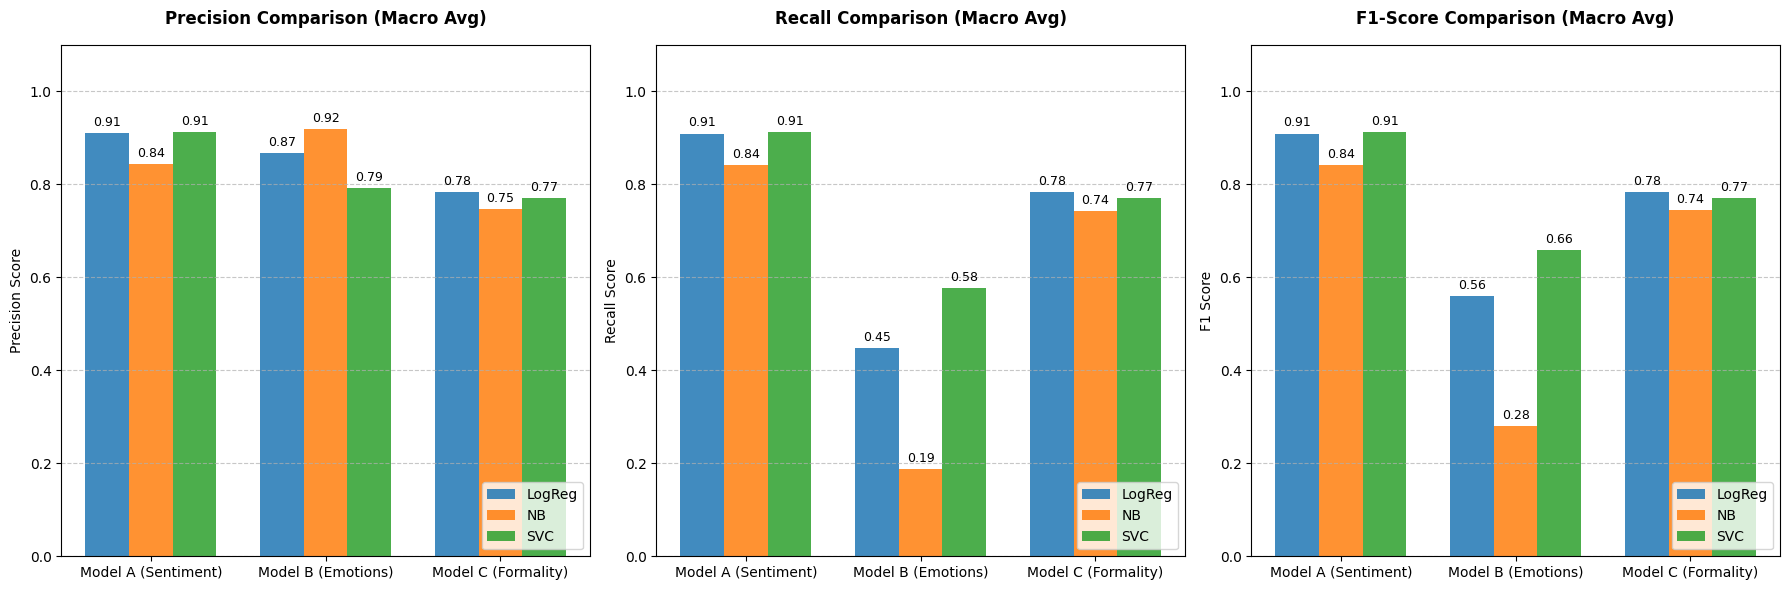

In [9]:
# cell 11: visual comparison of baseline models (macro average metrics)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred):
    """calculates macro precision, recall, and f1."""
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return p, r, f

# collect metrics
# note: using variables defined in previous cells (ensure they match your exact variable names)
metrics_a = {
    'LogReg': get_metrics(y_test_a, y_pred_a),
    'NB': get_metrics(y_test_a, y_pred_nb),
    'SVC': get_metrics(y_test_a, y_pred_svc_a)
}

metrics_b = {
    'LogReg': get_metrics(y_test_b, y_pred_b),
    'NB': get_metrics(y_test_b, y_pred_nb_b),
    'SVC': get_metrics(y_test_b, y_pred_svc_b)
}

metrics_c = {
    'LogReg': get_metrics(y_test_c, y_pred_c),
    'NB': get_metrics(y_test_c, y_pred_nb_c),
    'SVC': get_metrics(y_test_c, y_pred_svc_c)
}

algorithms = ['LogReg', 'NB', 'SVC']
tasks = ['Model A (Sentiment)', 'Model B (Emotions)', 'Model C (Formality)']

# unpack data for plotting
precision_data = [[metrics_a[alg][0], metrics_b[alg][0], metrics_c[alg][0]] for alg in algorithms]
recall_data = [[metrics_a[alg][1], metrics_b[alg][1], metrics_c[alg][1]] for alg in algorithms]
f1_data = [[metrics_a[alg][2], metrics_b[alg][2], metrics_c[alg][2]] for alg in algorithms]

# plotting setup
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_width = 0.25
x = np.arange(len(tasks))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

def plot_bar_chart(ax, data, title, ylabel):
    for i, (alg, color) in enumerate(zip(algorithms, colors)):
        bars = ax.bar(x + i*bar_width, data[i], bar_width, label=alg, color=color, alpha=0.85)
        # add text labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
            
    ax.set_title(title, pad=15, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(tasks)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

# plot the 3 charts
plot_bar_chart(axes[0], precision_data, 'Precision Comparison (Macro Avg)', 'Precision Score')
plot_bar_chart(axes[1], recall_data, 'Recall Comparison (Macro Avg)', 'Recall Score')
plot_bar_chart(axes[2], f1_data, 'F1-Score Comparison (Macro Avg)', 'F1 Score')

plt.tight_layout()
plt.show()

### baseline models export & project structure update

**what was saved & moved:**
1. **models:** linear svc models (`model_a_svc.pkl`, `model_b_svc_ovr.pkl`, `model_c_svc.pkl`) saved to `models/baselines/`. *(note: tf-idf vectorizers remain in `models/vectorizers/`).*
2. **code refactoring (mlops pipeline):**
   * `src/data/preprocess.py`: raw text cleaning (regex, spacy, emoji).
   * `src/features/build_features.py`: `TextVectorizer` class for loading pkls and applying `.transform()`.
   * `src/models/baselines.py`: `BaselineSVC` wrapper class for inference.
   * `src/evaluation/metrics.py`: macro metrics calculation and multi-model comparison logic.

**why:**
* **strict benchmarking:** we freeze these svc models as the absolute mathematical ceiling for the "bag of words" approach. any future neural network must beat these metrics to justify its complexity.
* **architecture standards:** separating data prep, feature extraction, and model inference into modular scripts keeps future jupyter notebooks clean and prevents code duplication during the neural network stage.

In [ ]:
# cell 12: exporting baseline models and vectorizers
import os
import joblib

print("creating directory and exporting artifacts...")

# create directory if it doesn't exist
os.makedirs('models/baselines', exist_ok=True)

# export trained svc models
joblib.dump(model_a_svc, 'models/baselines/model_a_svc.pkl')
joblib.dump(model_b_svc_ovr, 'models/baselines/model_b_svc_ovr.pkl')
joblib.dump(model_c_svc, 'models/baselines/model_c_svc.pkl')
print("- linear svc models saved.")

print("\nexport complete. all files are located in models/baselines/")

creating directory and exporting artifacts...
- linear svc models saved.

export complete. all files are located in models/baselines/
